In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import (
    WhiteKernel, ConstantKernel, RBF, RationalQuadratic, ExpSineSquared, DotProduct
)
from auto_kernel_ensemble import KernelAutoregressiveModel
from data_loader import DataLoader
from walk_forward import WalkForwardValidator

## Model Pipeline Testing

### Main Use:
Test out the functions in the classes created. Ensure all calculations are working as expected before fully simulating in backtesting


In [2]:
# load sample data and normalize it
sample_data  = pd.read_parquet('data/sample_data_for_testing_functions.parquet')

In [3]:
sample_data.head()

,Adj Close,Close,High,Low,Open,Volume,30 Day Avg,60 Day Avg,Running Mean,Running Median,...,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12,Lag 13,Lag 14,Lag 15
Date,,,,,,,,,,,,,,,,,,,,,
1982-03-23,3.869234,5.125,5.375,5.125,5.125,12100,-0.541301,-0.511199,3.575687,4.057978,...,-0.520053,-0.515095,-0.510845,-0.508366,-0.506241,-0.503408,-0.500575,-0.499159,-0.498096,-0.496680
1982-03-24,3.774863,5.000,5.125,5.000,5.125,7500,-0.543071,-0.513324,3.577154,4.057978,...,-0.524656,-0.520053,-0.515095,-0.510845,-0.508366,-0.506241,-0.503408,-0.500575,-0.499159,-0.498096
1982-03-25,3.680492,4.875,5.125,4.875,5.000,2000,-0.545550,-0.515095,3.578138,4.057978,...,-0.529260,-0.524656,-0.520053,-0.515095,-0.510845,-0.508366,-0.506241,-0.503408,-0.500575,-0.499159
1982-03-26,3.680492,4.875,5.125,4.875,4.875,3100,-0.548029,-0.517220,3.578645,4.010792,...,-0.533510,-0.529260,-0.524656,-0.520053,-0.515095,-0.510845,-0.508366,-0.506241,-0.503408,-0.500575
1982-03-29,3.491750,4.625,4.875,4.625,4.875,9600,-0.551217,-0.519521,3.579147,3.963607,...,-0.537405,-0.533510,-0.529260,-0.524656,-0.520053,-0.515095,-0.510845,-0.508366,-0.506241,-0.503408


In [4]:
# create the auto kernel regressive model
auto_kernel = KernelAutoregressiveModel(forecast_horizon=5, n_jobs=2)

INFO:auto_kernel_ensemble:Created 5 kernel configurations


In [5]:
# split the sample data
x_cols = [f'Lag {x + 1}' for x in range(15)]
y_col = '30 Day Avg'

# train the autoregressive model on the first 400 events
auto_kernel.train_historical(x=sample_data[x_cols].iloc[:400], y=sample_data[y_col].iloc[:400].to_frame())
print(f"model trained")




INFO:auto_kernel_ensemble:Training completed. Best kernel: {'kernel': 1**2 * DotProduct(sigma_0=1) + ExpSineSquared(length_scale=2, periodicity=20) + WhiteKernel(noise_level=1e-05)}, RMSE: 0.0017


model trained


In [6]:
test = sample_data.iloc[400:430]
predictions = []
for idx in test[x_cols].index:
    x_vals = test[x_cols].loc[[idx]]
    single_prediction = auto_kernel.predict_val(x_vals)
    predictions.append(single_prediction[0])

len(predictions)

30

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76032/2693856851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = predictions
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76032/2693856851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['30 Day Avg future value'] = test['30 Day Avg'].shift(-4)


<Axes: xlabel='Date'>

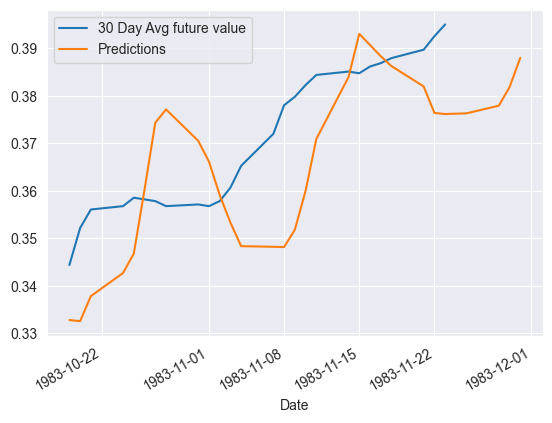

In [7]:
test['Predictions'] = predictions
test['30 Day Avg future value'] = test['30 Day Avg'].shift(-4)
test[['30 Day Avg future value', 'Predictions']].plot()

In [8]:
predictions = []
max_predictions = []
min_predictions = []
for idx in test[x_cols].index:
    x_vals = test[x_cols].loc[[idx]]
    single_prediction = auto_kernel.predict_val_distribution(x_vals, sample_data[y_col].to_frame())
    predictions.append(float(single_prediction.mean().values[0]))
    max_predictions.append(float(single_prediction.max().values[0]))
    min_predictions.append(float(single_prediction.min().values[0]))

len(predictions)

30

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76032/4089604412.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Max Predictions'] = max_predictions
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76032/4089604412.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Min Predictions'] = min_predictions
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76032/4089604412.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

<Axes: xlabel='Date'>

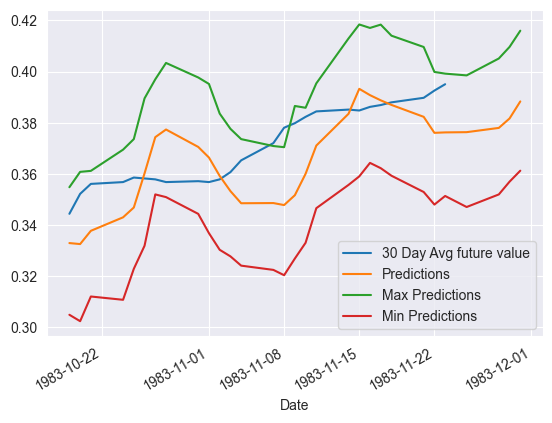

In [9]:
test['Max Predictions'] = max_predictions
test['Min Predictions'] = min_predictions
test['Predictions'] = predictions
test[['30 Day Avg future value', 'Predictions', 'Max Predictions', 'Min Predictions']].plot()

In [10]:
data_load = DataLoader(data_path='data/sample_data_for_testing_functions.parquet')
auto_kernel = KernelAutoregressiveModel(forecast_horizon=7, n_jobs=2)
data_load.load_data(x=x_cols, y=['30 Day Avg'], actuals=['30 Day Avg'])
walks = WalkForwardValidator(
    model=auto_kernel,
    data_loader=data_load,
    ticker='RGLD',
    lags=15,
    # forecast_horizon=5,
    # n_jobs=2,
    window_size=400,
    min_window_size=400,
    n_parallel_jobs=2,
    window_type='growing'
)
walks.run_walk_forward_validation(target_variable='30 Day Avg')

INFO:data_loader:Loading data from data/sample_data_for_testing_functions.parquet
INFO:data_loader:Loaded data: 500 rows, 16 columns
INFO:data_loader:Date range: 1982-03-23 00:00:00 to 1984-03-12 00:00:00
INFO:walk_forward:Initialized walk-forward validator: window_size=400, min_window_size=400, step_size=1
INFO:walk_forward:Starting walk-forward validation for RGLD
INFO:data_loader:Generated 100 growing time windows
INFO:walk_forward:Running 100 predictions with 15 features
Running Walk Forward Validation: 100%|██████████| 100/100 [00:18<00:00,  5.36it/s]


In [14]:
df_summary = pd.DataFrame(walks.model_summaries)
df_summary.head()

,model_type,forecast_horizon,n_lags,best_params,training_scores,is_trained,date,feature_importance
0,KernelAutoregressiveModel,5,5,{'kernel_config': {'kernel': 1**2 * DotProduct...,"{'mse': 3.0530327495427206e-06, 'rmse': 0.0017...",True,1983-10-19,"{'Lag 1': 1.2256713789560416, 'Lag 2': 1.22567..."
1,KernelAutoregressiveModel,5,5,{'kernel_config': {'kernel': 1**2 * DotProduct...,"{'mse': 3.0530327495427206e-06, 'rmse': 0.0017...",True,1983-10-20,"{'Lag 1': 1.2256713789560416, 'Lag 2': 1.22567..."
2,KernelAutoregressiveModel,5,5,{'kernel_config': {'kernel': 1**2 * DotProduct...,"{'mse': 3.0530327495427206e-06, 'rmse': 0.0017...",True,1983-10-21,"{'Lag 1': 1.2256713789560416, 'Lag 2': 1.22567..."
3,KernelAutoregressiveModel,5,5,{'kernel_config': {'kernel': 1**2 * DotProduct...,"{'mse': 3.0530327495427206e-06, 'rmse': 0.0017...",True,1983-10-24,"{'Lag 1': 1.2256713789560416, 'Lag 2': 1.22567..."
4,KernelAutoregressiveModel,5,5,{'kernel_config': {'kernel': 1**2 * DotProduct...,"{'mse': 3.0530327495427206e-06, 'rmse': 0.0017...",True,1983-10-25,"{'Lag 1': 1.2256713789560416, 'Lag 2': 1.22567..."


In [16]:
results_df = pd.DataFrame(walks.results_list)
results_df.head()

,date,actual_value,prediction,best_kernel,best_alpha,retrain
0,1983-10-19,[[0.3316466830679892]],[0.3328166388536289],Sum,None,True
1,1983-10-20,[[0.33341737910583796]],[0.3325662366745181],Sum,None,False
2,1983-10-21,[[0.33518807514368665]],[0.33784712042095855],Sum,None,False
3,1983-10-24,[[0.33731289822138977]],[0.3427155475899468],Sum,None,False
4,1983-10-25,[[0.34439563942790685]],[0.3468157945413761],Sum,None,False


<Axes: >

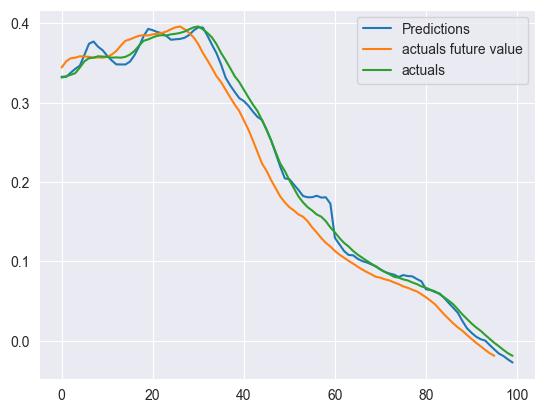

In [18]:
# Transform the predictions
results_df['Predictions'] = results_df['prediction'].apply(lambda x: float(x[0]))
results_df['actuals'] = results_df['actual_value'].apply(lambda x: float(x[0][0]))
results_df['actuals future value'] = results_df['actuals'].shift(-4)

# plot
results_df[['Predictions', 'actuals future value', 'actuals']].plot()

<Axes: >

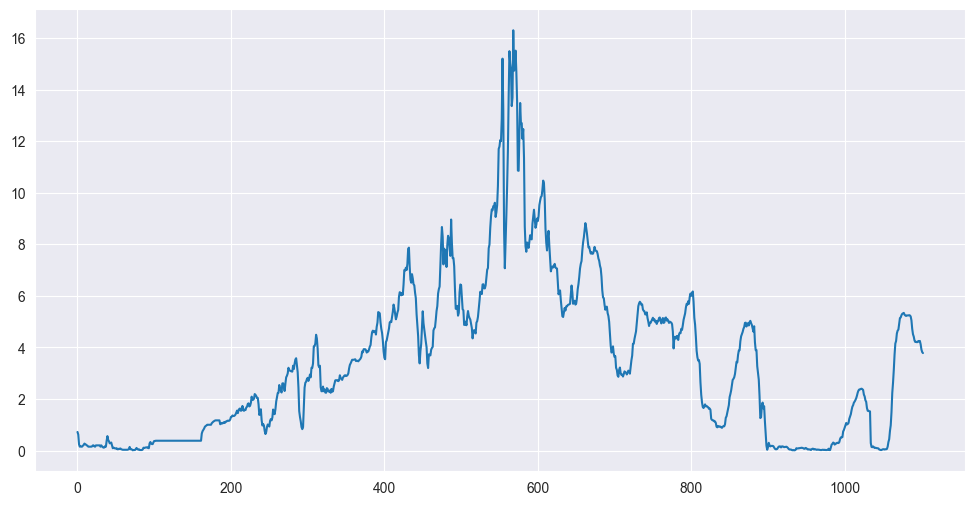

In [4]:
# create the risk free rate
three_month_rate = pd.read_csv('data/TB3MS.csv')
three_month_rate['TB3MS'].plot(figsize=(12, 6))

In [7]:
three_month_rate['date'] = pd.to_datetime(three_month_rate['observation_date'])
three_month_rate[['date', 'TB3MS']].to_parquet('data/risk_free_rate.parquet')
print("Saved risk free rate")

Saved risk free rate


In [10]:
portfolio_assets = [
        'ACM',
        'OSK',
        'PATH',
        'RGLD',
        'AAAU',
        'CIBR',
        'IBIT',
        'ITA',
        'SGDM',
        'USO',
        'USXF',
        'XHE'
    ]
# get the results
results = {}
for ticker in portfolio_assets:
    try:
        df = pd.read_parquet(f'data/results/{ticker}/auto_kernel/{ticker}_results.parquet')
        # perform transformations
        df['Predictions'] = round(df['prediction'].apply(lambda x: float(x[0])), 3)
        df['actuals'] = round(df['actual_value'].apply(lambda x: float(x[0][0])), 3)
        results[ticker] = df
    except Exception as e:
        print(f"Error loading results for {ticker}: {e}\n{df.head()}")
print(f"Loaded all results")

Error loading results for PATH: 'prediction'
Empty DataFrame
Columns: []
Index: []
Error loading results for AAAU: 'prediction'
Empty DataFrame
Columns: []
Index: []
Error loading results for IBIT: 'prediction'
Empty DataFrame
Columns: []
Index: []
Error loading results for USXF: 'prediction'
Empty DataFrame
Columns: []
Index: []
Loaded all results


In [8]:
len(results.keys())

8

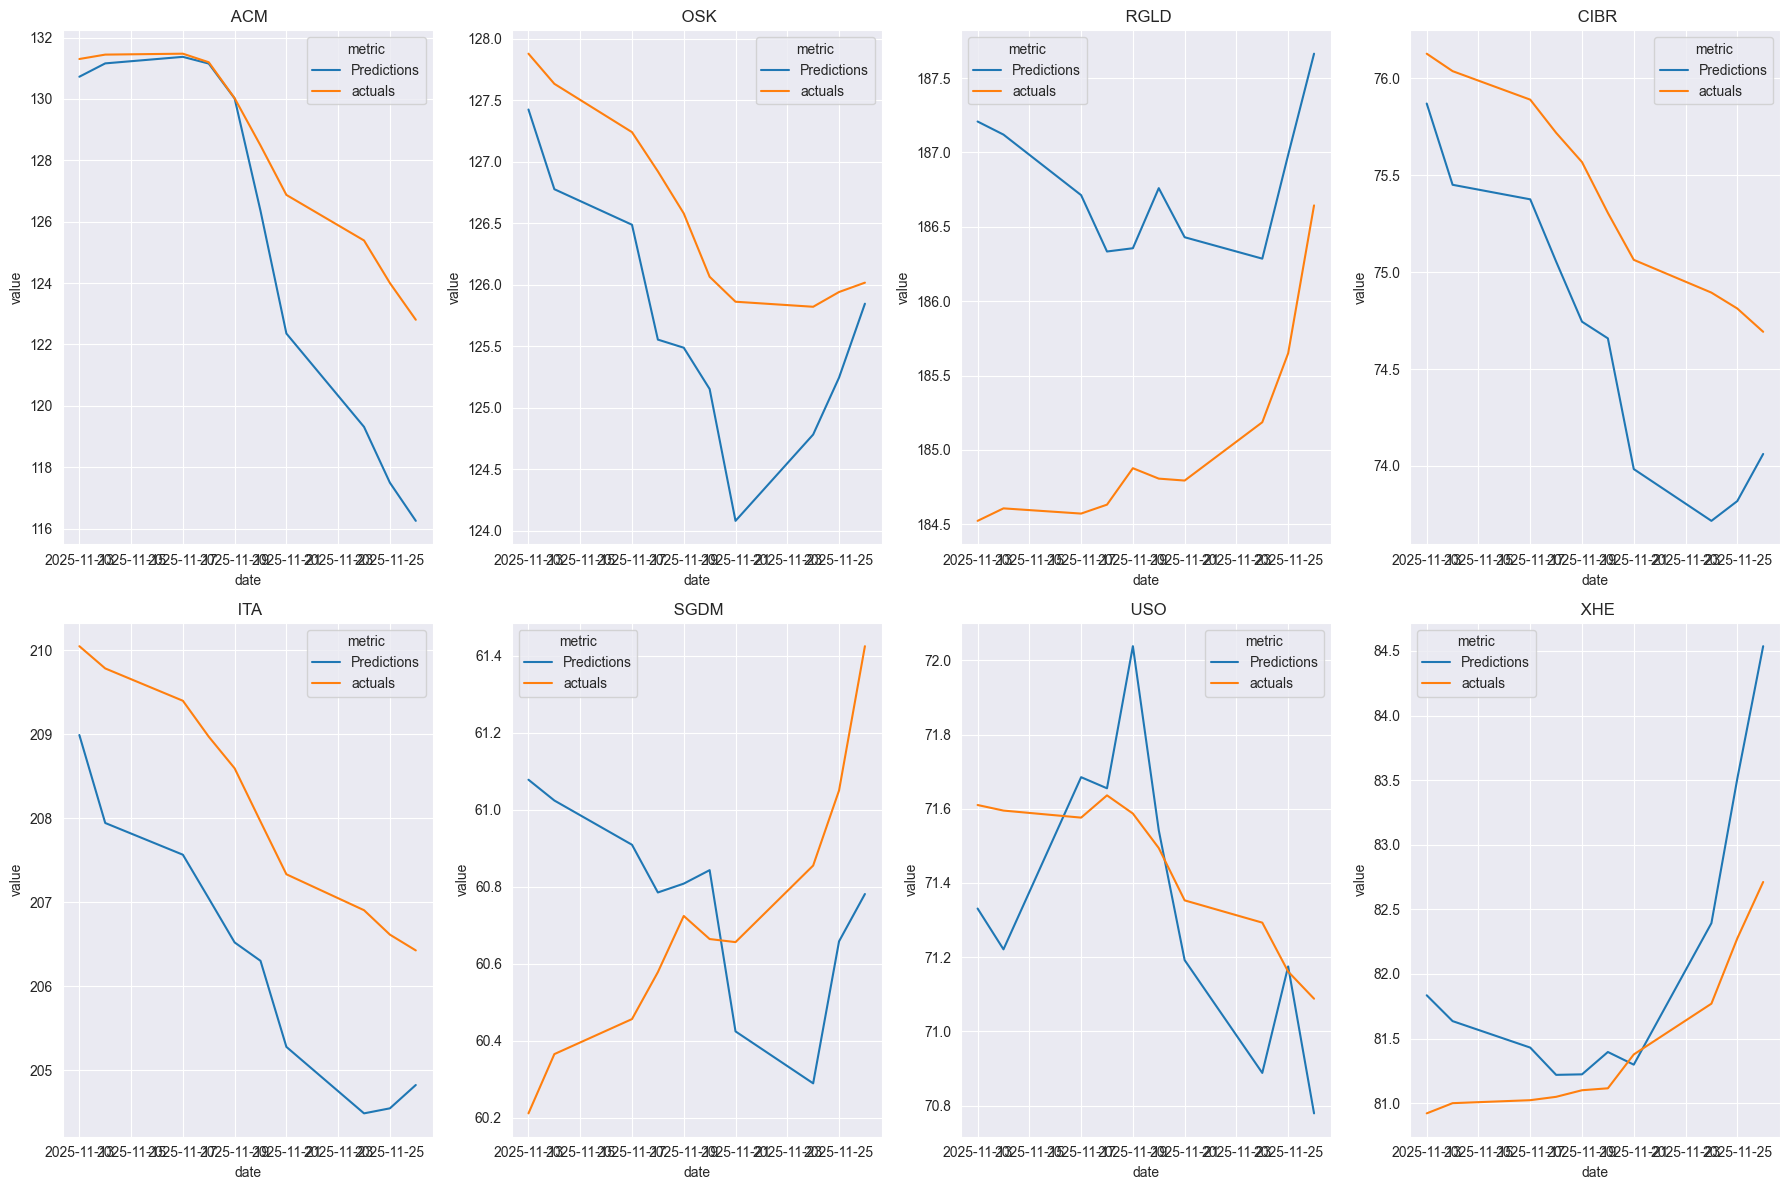

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()
# counter = 0
for counter, ticker in enumerate(results.keys()):
    df_melted = results[ticker].reset_index()
    df_melted = df_melted.melt(id_vars=['date'], value_vars=['Predictions', 'actuals'], var_name='metric', value_name='value')
    sns.lineplot(df_melted, x='date', y='value', hue='metric', ax=axes[counter])
    axes[counter].set_title(f" {ticker}")
    counter += 1

plt.tight_layout()
plt.show()

In [16]:
df_melted

,index,date,actual_value,prediction,best_kernel,best_alpha,retrain,Predictions,actuals
0,0,2025-11-13,[[131.30261010224467]],[130.72497683438866],Sum,None,True,130.725,131.303
1,1,2025-11-14,[[131.44566779064573]],[131.1602504324378],Sum,None,False,131.160,131.446
2,2,2025-11-17,[[131.47626975053603]],[131.37273435875102],Sum,None,False,131.373,131.476
3,3,2025-11-18,[[131.19651037241425]],[131.15404839461553],Sum,None,False,131.154,131.197
4,4,2025-11-19,[[130.0244773664067]],[130.01691485842736],Sum,None,False,130.017,130.024
5,5,2025-11-20,[[128.48354330339004]],[126.35215205014075],Sum,None,False,126.352,128.484
6,6,2025-11-21,[[126.87299190594982]],[122.35535729711202],Sum,None,False,122.355,126.873
7,7,2025-11-24,[[125.38763749099313]],[119.31247097770132],Sum,None,False,119.312,125.388
8,8,2025-11-25,[[124.00004779824636]],[117.49213970260303],Sum,None,False,117.492,124.000
9,9,2025-11-26,[[122.80391562316419]],[116.2494264190396],Sum,None,False,116.249,122.804


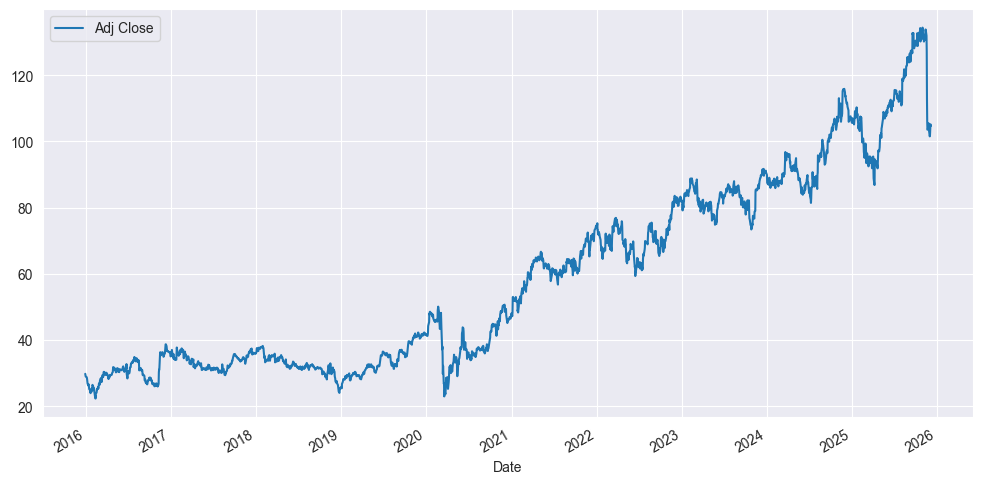

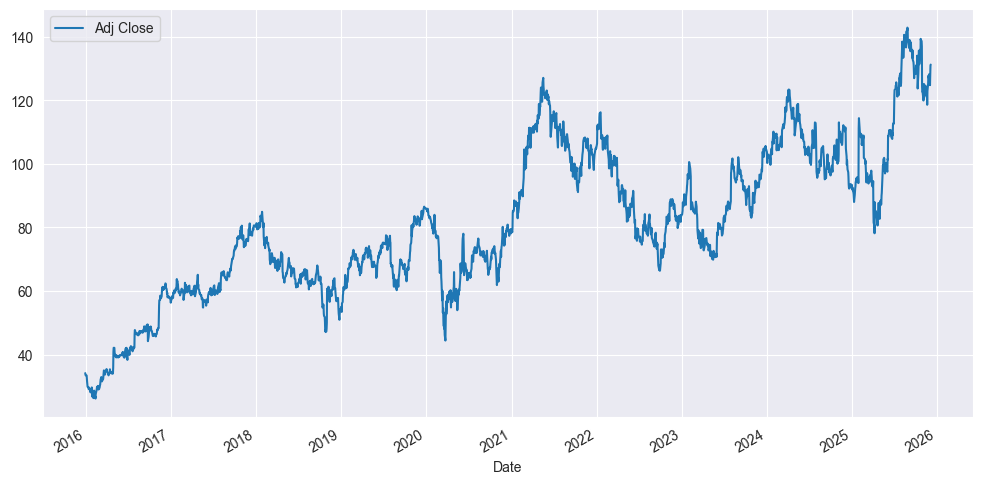

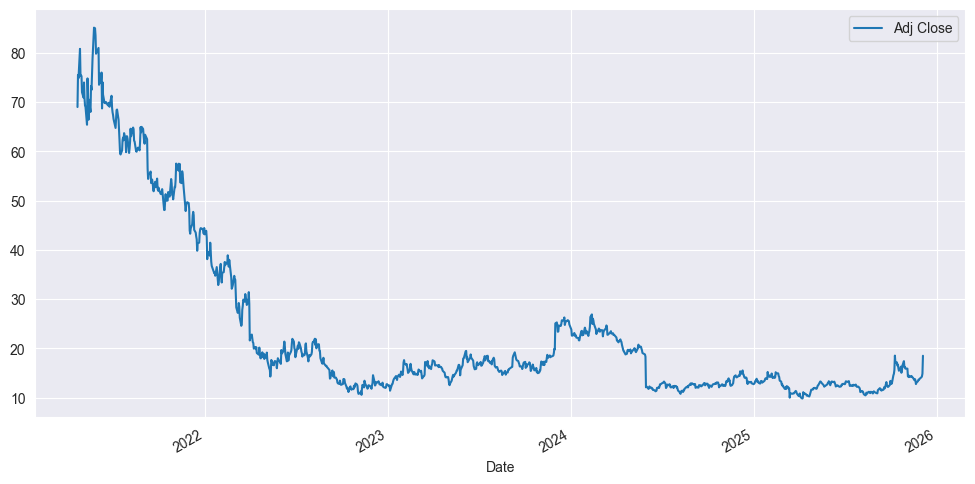

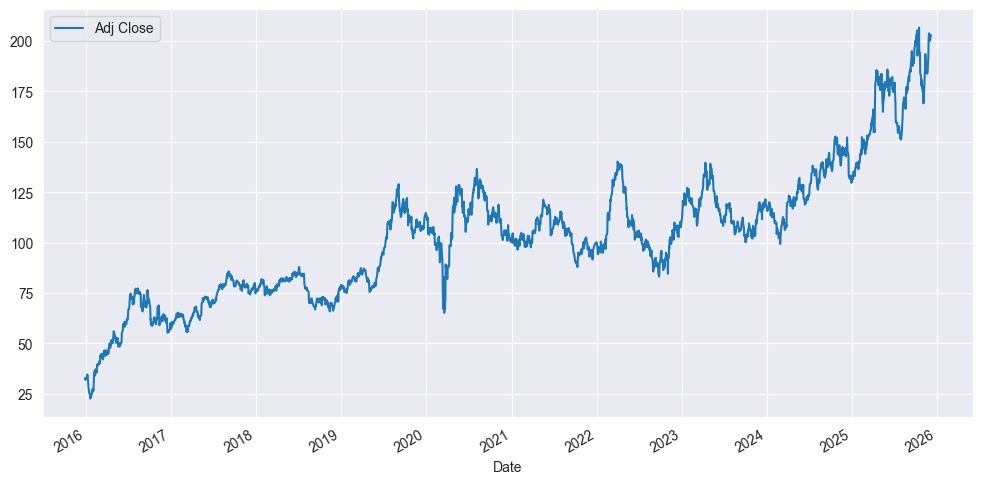

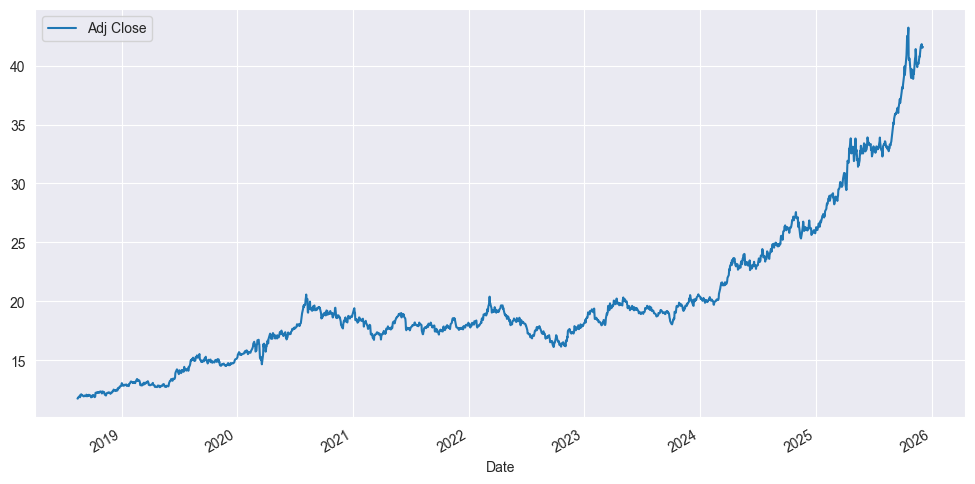

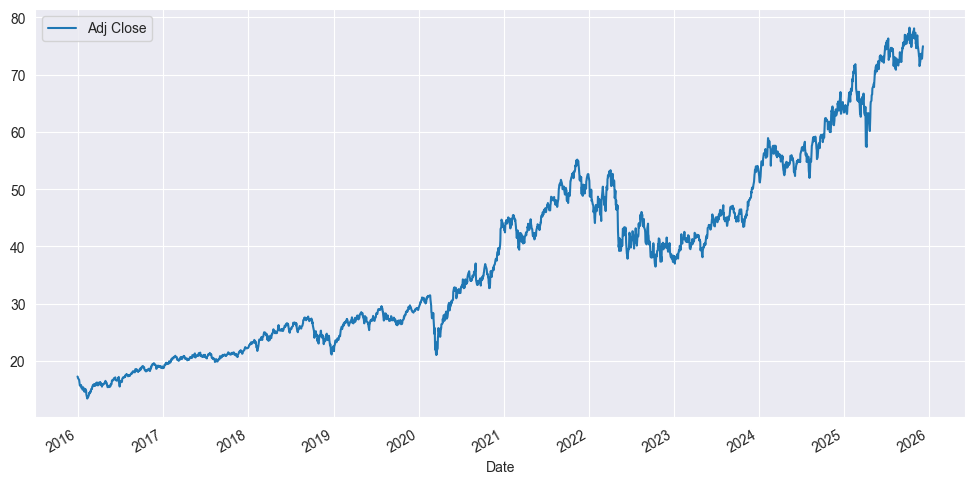

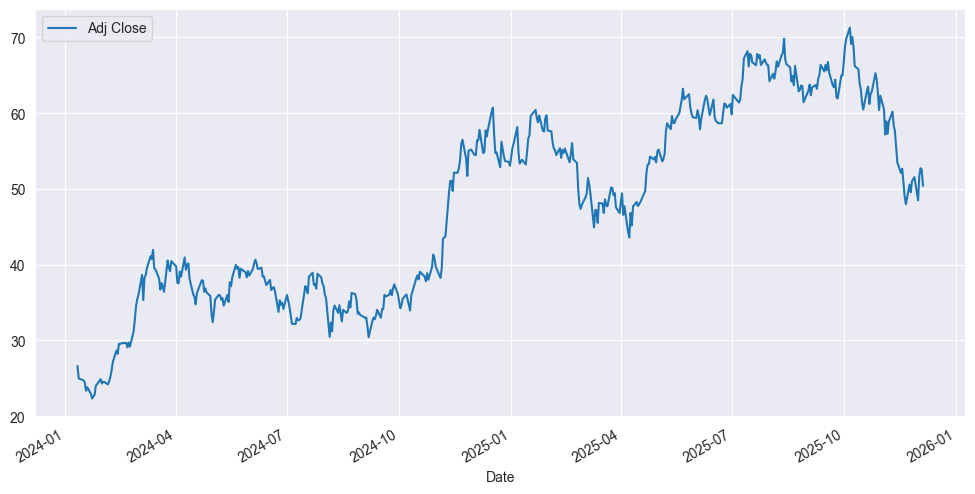

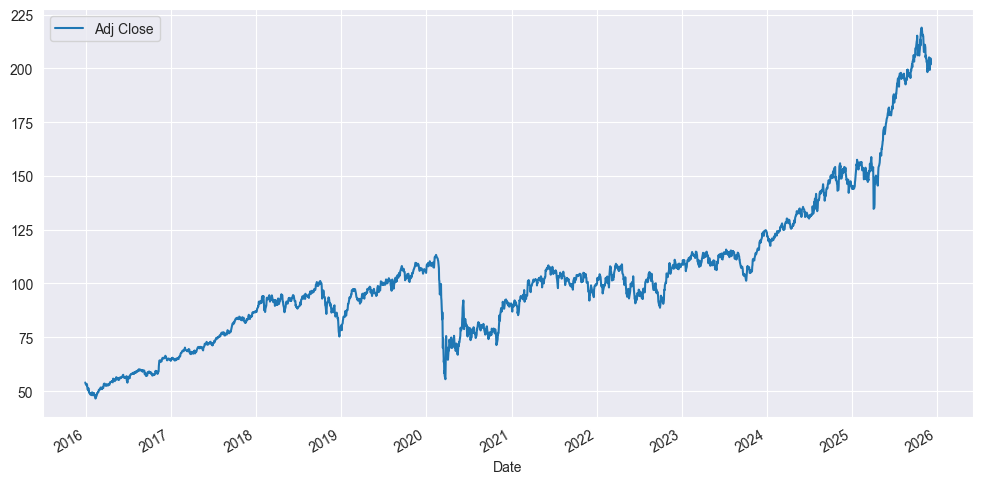

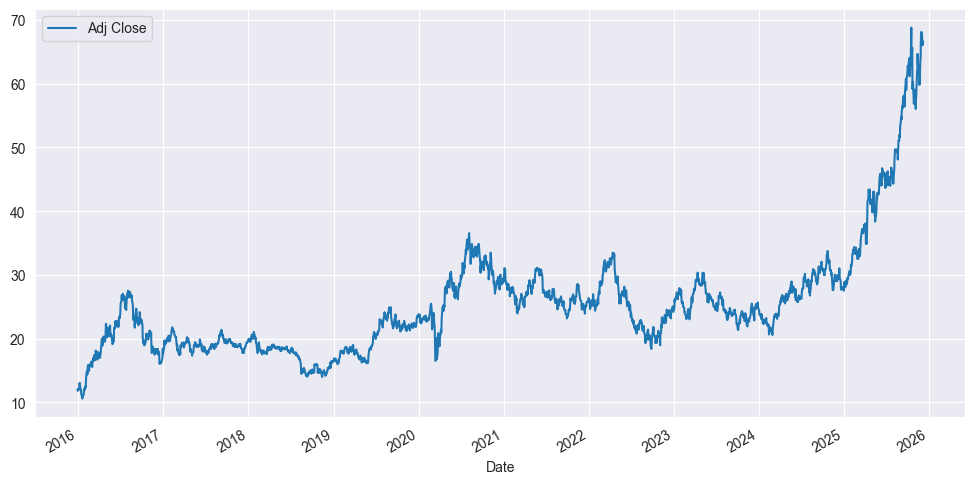

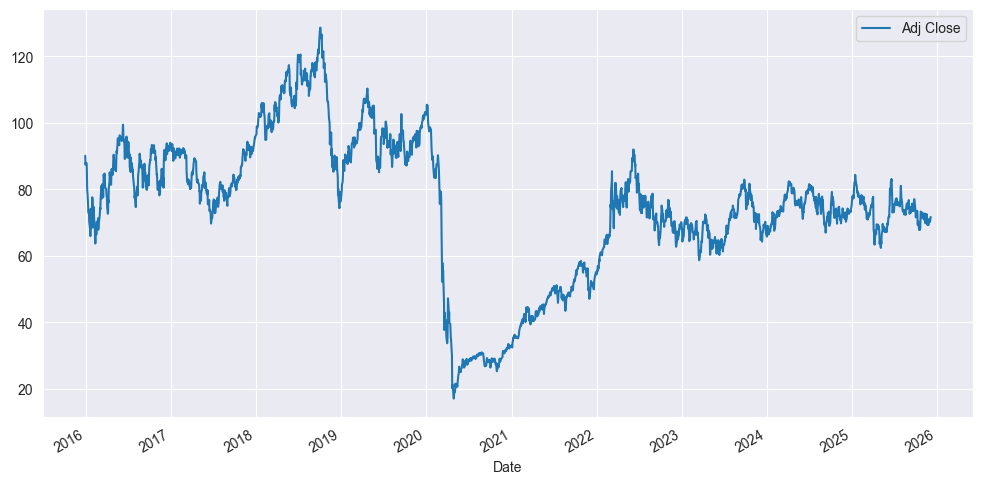

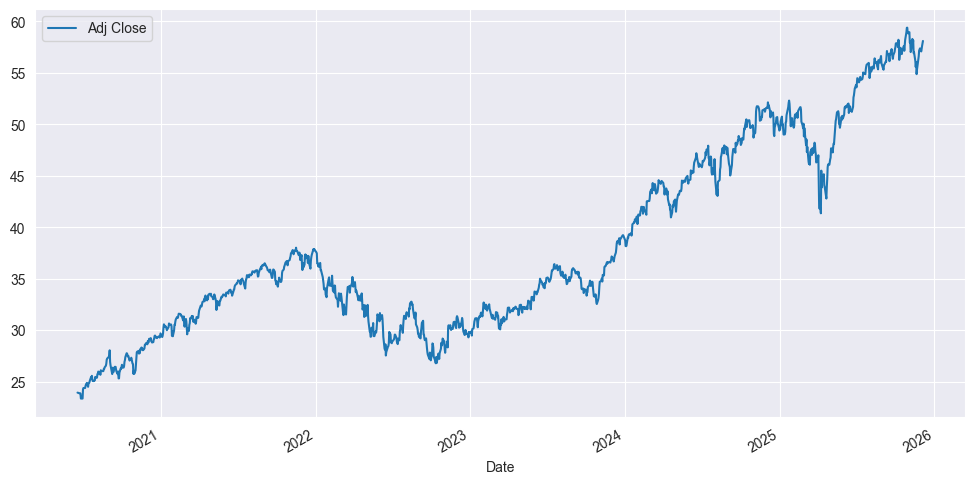

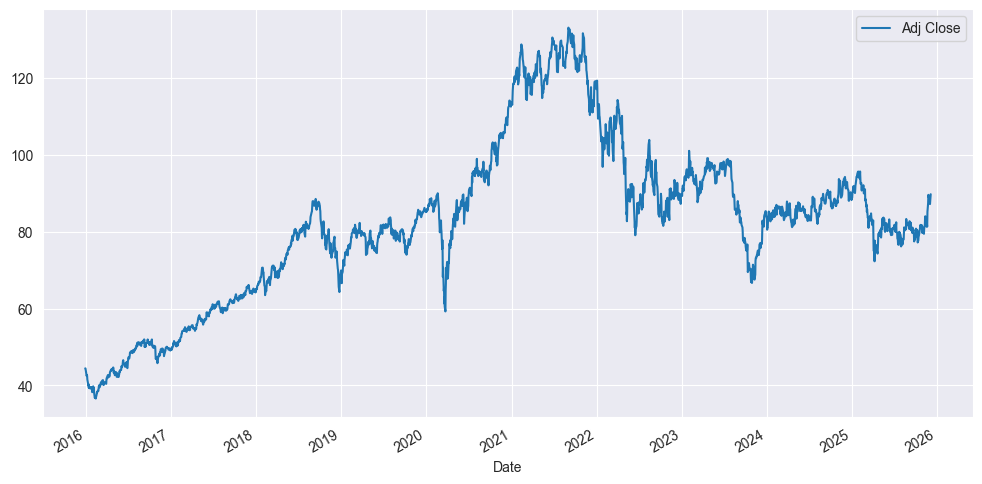

In [18]:
# plot the last 2500 records for the portfolio assets
for ticker in portfolio_assets:
    df = pd.read_parquet(f'data/{ticker}.parquet')
    df[['Adj Close']].tail(2500).plot(figsize=(12, 6))